QUESTION 1 -

 Explain the difference between:

● "r", "w", "a", "rb"

● Why context managers (with open()) are preferred

● What happens if a file is not properly closed in a production system

- Difference between "r", "w", "a", "rb"

  - "r" → Opens file for reading only. File must exist.

  - "w" → Opens file for writing. Old data is overwritten.

  - "a" → Opens file for appending data at the end of file.

  - "rb" → Opens file in binary read mode (used for images, videos, PDFs, etc.).

 - Why with open() is Preferred

     -  Automatically closes the file after use.
     -  Prevents memory and resource leaks.
     -  Handles errors safely.
     -  Makes code cleaner and easier to read.

Example:


with open("file.txt", "r") as f:

    data = f.read()

- What Happens if a File Is Not Properly Closed
   - System resources get wasted.
   - Too many open files may crash the program.
   - Data may not be saved correctly.
   - File may remain locked for other users/programs.

Example error:

OSError: Too many open files

QUESTION 2:

You are given a CSV file sales.csv containing:

product,price,quantity

Laptop,50000,5


Phone,20000,10

Tablet,15000,7

Tasks:

1. Read the file using Python.
2. Compute total revenue per product.
3. Write results to a new file revenue.csv.
4. Explain limitations of manual CSV handling vs Pandas.

In [8]:
import csv

# Step 1: Create sales.csv file
with open("sales.csv", "w", newline="") as file:
    writer = csv.writer(file)

    # Header
    writer.writerow(["product", "price", "quantity"])

    # Data
    writer.writerow(["Laptop", 50000, 5])
    writer.writerow(["Phone", 20000, 10])
    writer.writerow(["Tablet", 15000, 7])

print("sales.csv created successfully")


# Step 2: Read sales.csv and calculate revenue
with open("sales.csv", "r") as file:
    reader = csv.reader(file)
    next(reader)   # Skip header

    # Step 3: Create revenue.csv
    with open("revenue.csv", "w", newline="") as output:
        writer = csv.writer(output)

        # Header
        writer.writerow(["product", "revenue"])

        # Revenue calculation
        for row in reader:
            product = row[0]
            price = int(row[1])
            quantity = int(row[2])

            revenue = price * quantity

            writer.writerow([product, revenue])

print("revenue.csv created successfully")


# Display revenue.csv content
with open("revenue.csv", "r") as file:
    print("\nContents of revenue.csv:\n")
    print(file.read())

sales.csv created successfully
revenue.csv created successfully

Contents of revenue.csv:

product,revenue
Laptop,250000
Phone,200000
Tablet,105000



- Limitations of Manual CSV Handling vs Pandas
  - Manual CSV handling needs more code.
  - Difficult for large datasets.
  - No built-in data analysis functions.
  - Filtering and calculations are slower.
  - Pandas provides easy DataFrame operations and faster processing.

QUESTION 3:
You receive JSON data from an API:

{

"customers": [

{"id": 1, "name": "Amit", "purchase": 5000},

{"id": 2, "name": "Sara", "purchase": 7000}

]

}

Tasks:
1. Load the JSON.
2. Extract all customer names.
3. Compute total purchase value.
4. Explain why JSON is widely used in ML pipelines.


In [9]:
import json

# Step 1: JSON data
data = '''
{
    "customers": [
        {"id": 1, "name": "Amit", "purchase": 5000},
        {"id": 2, "name": "Sara", "purchase": 7000}
    ]
}
'''

# Load JSON
parsed_data = json.loads(data)

# Step 2: Extract customer names
names = []

for customer in parsed_data["customers"]:
    names.append(customer["name"])

print("Customer Names:", names)

# Step 3: Compute total purchase value
total_purchase = 0

for customer in parsed_data["customers"]:
    total_purchase += customer["purchase"]

print("Total Purchase Value:", total_purchase)

Customer Names: ['Amit', 'Sara']
Total Purchase Value: 12000


- Why JSON is Widely Used in ML Pipelines
  - JSON is lightweight and easy to read.
  - It stores data in key-value format.
  - Easy data exchange between APIs and ML models.
  - Supported by Python and most programming languages.
  - Useful for storing configurations, datasets, and model results.

QUESTION 4:
Create NumPy arrays for:

● Product prices

● Quantities

Then:
1. Compute revenue using vectorized operations.
2. Compare performance of Python loop vs NumPy.
3. Explain broadcasting with example.


In [10]:
import numpy as np
import time

# Create NumPy arrays
prices = np.array([50000, 20000, 15000])
quantities = np.array([5, 10, 7])

# Step 1: Compute revenue using vectorized operations
revenue = prices * quantities

print("Revenue per product:", revenue)
print("Total Revenue:", np.sum(revenue))


# Step 2: Compare Python loop vs NumPy

# Python loop
start = time.time()

total = 0
for i in range(len(prices)):
    total += prices[i] * quantities[i]

end = time.time()

print("\nPython Loop Total:", total)
print("Python Loop Time:", end - start)


# NumPy vectorized operation
start = time.time()

total_numpy = np.sum(prices * quantities)

end = time.time()

print("\nNumPy Total:", total_numpy)
print("NumPy Time:", end - start)

Revenue per product: [250000 200000 105000]
Total Revenue: 555000

Python Loop Total: 555000
Python Loop Time: 0.0031507015228271484

NumPy Total: 555000
NumPy Time: 0.00016236305236816406


- Python Loop vs NumPy
  - Python loops are slower because elements are processed one by one.
  - NumPy uses vectorized operations which are faster and optimized in C.
  - NumPy is preferred for large datasets and ML applications.


 - Broadcasting in NumPy

    - Broadcasting means NumPy automatically adjusts array sizes to perform operations.

In [12]:
#example -
arr = np.array([1, 2, 3])

result = arr + 10

print(result)

[11 12 13]


QUESTION 5:

Using sales data:

1. Plot line chart for monthly revenue.
2. Plot bar chart for product comparison.
3. Add labels, title, legend.
4. Explain why visualization is essential before modeling.

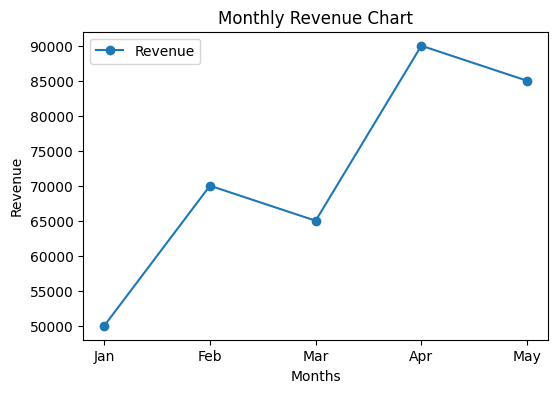

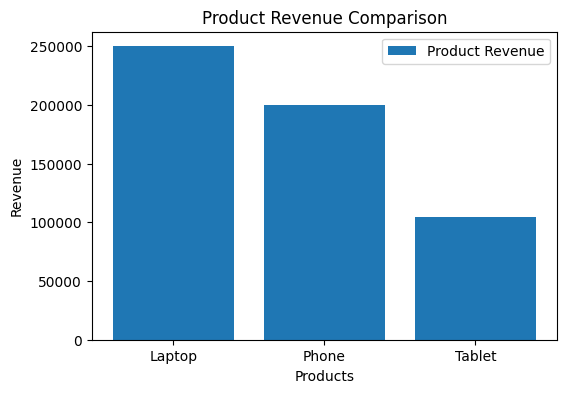

In [13]:
import matplotlib.pyplot as plt

# Monthly revenue data
months = ["Jan", "Feb", "Mar", "Apr", "May"]
revenue = [50000, 70000, 65000, 90000, 85000]

# Product comparison data
products = ["Laptop", "Phone", "Tablet"]
sales = [250000, 200000, 105000]

# Step 1: Line chart for monthly revenue
plt.figure(figsize=(6,4))

plt.plot(months, revenue, marker='o', label="Revenue")

plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Chart")
plt.legend()

plt.show()


# Step 2: Bar chart for product comparison
plt.figure(figsize=(6,4))

plt.bar(products, sales, label="Product Revenue")

plt.xlabel("Products")
plt.ylabel("Revenue")
plt.title("Product Revenue Comparison")
plt.legend()

plt.show()

- Why Visualization is Essential Before Modeling
  - Helps understand the data clearly.
  - Identifies trends and patterns.
  - Detects missing values and outliers.
  - Makes comparison easier.
  - Improves decision-making before applying ML models.

QUESTION 6:

Load a CSV into Pandas and:

1. Display first 5 rows.
2. Check missing values.
3. Compute summary statistics.
4. Select rows where sales > 15000.


In [14]:
import pandas as pd

# Create sample CSV file
data = {
    "product": ["Laptop", "Phone", "Tablet", "Monitor", "Keyboard"],
    "sales": [50000, 20000, 15000, 12000, 8000]
}

df = pd.DataFrame(data)

# Save as CSV
df.to_csv("sales.csv", index=False)

# Load CSV into Pandas
df = pd.read_csv("sales.csv")

# Step 1: Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Step 2: Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3: Compute summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Step 4: Select rows where sales > 15000
print("\nRows where sales > 15000:")
print(df[df["sales"] > 15000])

First 5 Rows:
    product  sales
0    Laptop  50000
1     Phone  20000
2    Tablet  15000
3   Monitor  12000
4  Keyboard   8000

Missing Values:
product    0
sales      0
dtype: int64

Summary Statistics:
              sales
count      5.000000
mean   21000.000000
std    16792.855624
min     8000.000000
25%    12000.000000
50%    15000.000000
75%    20000.000000
max    50000.000000

Rows where sales > 15000:
  product  sales
0  Laptop  50000
1   Phone  20000


QUESTION 7:

 Dataset contains:

● Missing values

● Duplicate rows

● Inconsistent capitalization

Tasks:
1. Remove duplicates.
2. Handle missing values.
3. Standardize text columns.
4. Explain impact of dirty data on ML performance.


In [15]:
import pandas as pd

# Sample dataset
data = {
    "Name": ["Amit", "Sara", "amit", None, "Sara"],
    "Sales": [5000, 7000, 5000, 6000, 7000]
}

df = pd.DataFrame(data)

print("Original Data:\n")
print(df)

# Step 1: Remove duplicate rows
df = df.drop_duplicates()

# Step 2: Handle missing values
df["Name"] = df["Name"].fillna("Unknown")

# Step 3: Standardize text columns
df["Name"] = df["Name"].str.lower()

print("\nCleaned Data:\n")
print(df)

Original Data:

   Name  Sales
0  Amit   5000
1  Sara   7000
2  amit   5000
3  None   6000
4  Sara   7000

Cleaned Data:

      Name  Sales
0     amit   5000
1     sara   7000
2     amit   5000
3  unknown   6000


- Impact of Dirty Data on ML Performance
  - Reduces model accuracy.
  - Produces incorrect predictions.
  - Increases training time.
  - Creates bias and inconsistency in results.
  - Poor quality data leads to unreliable ML models.

QUESTION 8:

Using Plotly:

1. Create interactive bar chart of sales.
2. Create pie chart for category distribution.
3. Add hover information.
4. Explain difference between:

○ Static visualization (Matplotlib/Seaborn)

○ Interactive dashboards (Plotly)

Discuss where interactive dashboards are critical in business environments.

In [16]:
import plotly.express as px
import pandas as pd

# Sample sales data
data = {
    "Product": ["Laptop", "Phone", "Tablet", "Monitor"],
    "Sales": [250000, 200000, 105000, 80000],
    "Category": ["Electronics", "Electronics", "Electronics", "Accessories"]
}

df = pd.DataFrame(data)

# Step 1: Interactive Bar Chart
fig_bar = px.bar(
    df,
    x="Product",
    y="Sales",
    color="Product",
    title="Product Sales Comparison",
    hover_data=["Sales"]
)

fig_bar.show()


# Step 2: Pie Chart for Category Distribution
category_data = df.groupby("Category")["Sales"].sum().reset_index()

fig_pie = px.pie(
    category_data,
    names="Category",
    values="Sales",
    title="Category Distribution",
    hover_data=["Sales"]
)

fig_pie.show()

| Static Visualization        | Interactive Dashboards       |
| --------------------------- | ---------------------------- |
| Uses Matplotlib and Seaborn | Uses Plotly and Dash         |
| Fixed charts                | User can zoom, filter, hover |
| Best for reports and PDFs   | Best for live dashboards     |
| Less user interaction       | Highly interactive           |
| Simpler and lightweight     | More dynamic and engaging    |


- Where Interactive Dashboards Are Critical in Business
  - Sales and revenue monitoring
  - Real-time stock market analysis
  - Customer behavior tracking
  - Business intelligence dashboards
  - Healthcare and financial analytics
  - KPI monitoring and decision-making systems

QUESTION 9:

Write a Python program to:

1. Create a text file called data.txt
2. Write 5 lines of product information
3. Read the file and print only lines containing the word "Laptop"
4. Use a context manager

Explain why context managers prevent memory leaks

In [17]:
# Step 1 & 2: Create data.txt and write product information

with open("data.txt", "w") as file:
    file.write("Laptop - 50000\n")
    file.write("Phone - 20000\n")
    file.write("Tablet - 15000\n")
    file.write("Laptop Pro - 75000\n")
    file.write("Monitor - 12000\n")

print("data.txt created successfully")


# Step 3: Read file and print lines containing 'Laptop'

print("\nLines containing 'Laptop':\n")

with open("data.txt", "r") as file:
    for line in file:
        if "Laptop" in line:
            print(line.strip())

data.txt created successfully

Lines containing 'Laptop':

Laptop - 50000
Laptop Pro - 75000


- Why Context Managers Prevent Memory Leaks
  - Context managers automatically close files after use.
  - They release system resources properly.
  - Prevents too many files remaining open in memory.
  - Safer when errors or exceptions occur.
  - Helps avoid memory leaks and improves program stability.

QUESTION 10:

 You are hired as a Data Analyst at an online learning company.

The company offers multiple courses and wants to understand:

● Revenue trends

● Student performance

● Course popularity

● Engagement patterns

You must design a simple analytics solution using Python and Data Science tools.

Design a CSV file structure that stores:

● Course Name

● Student ID

● Course Fee

● Completion Percentage

● Rating (1–5)

Write a Python program to:

1. Create this CSV file.
2. Add at least 10 sample records.
3. Read the file and calculate total revenue.

Explain why using with open() is better than manually opening and closing files.


In [18]:
import csv

# Step 1: Create CSV file and add sample records

with open("courses.csv", "w", newline="") as file:
    writer = csv.writer(file)

    # Header
    writer.writerow([
        "Course Name",
        "Student ID",
        "Course Fee",
        "Completion Percentage",
        "Rating"
    ])

    # Step 2: Add 10 sample records
    writer.writerow(["Python", 101, 5000, 90, 5])
    writer.writerow(["Data Science", 102, 7000, 85, 4])
    writer.writerow(["Machine Learning", 103, 8000, 75, 5])
    writer.writerow(["AI Basics", 104, 6000, 80, 4])
    writer.writerow(["Web Development", 105, 5500, 95, 5])
    writer.writerow(["Cyber Security", 106, 7500, 70, 4])
    writer.writerow(["Cloud Computing", 107, 6500, 88, 5])
    writer.writerow(["Java", 108, 4000, 92, 4])
    writer.writerow(["SQL", 109, 3000, 98, 5])
    writer.writerow(["Power BI", 110, 4500, 85, 4])

print("courses.csv created successfully")


# Step 3: Read the file and calculate total revenue

total_revenue = 0

with open("courses.csv", "r") as file:
    reader = csv.reader(file)

    next(reader)   # Skip header

    for row in reader:
        fee = int(row[2])
        total_revenue += fee

print("\nTotal Revenue:", total_revenue)

courses.csv created successfully

Total Revenue: 57000


- Why with open() is Better
  - Automatically closes the file after use.
  - Prevents memory and resource leaks.
  - Safer if errors occur during execution.
  - Makes code cleaner and easier to read.
  - Improves program reliability in real applications.